# Phase 4: Model Implementation - Bidirectional LSTM (Bi-LSTM)

Pada notebook ini kita akan membangun, melatih, dan mengevaluasi model **Bidirectional LSTM**.
LSTM sangat baik dalam menangkap long-range dependencies pada sekuens asam amino, memahami "grammar" urutan protein dalam menentukan fungsi.

In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import json

# Set device ke CUDA jika tersedia
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan device: {device}")

os.makedirs('models', exist_ok=True)
os.makedirs('data/results', exist_ok=True)

Menggunakan device: cuda


In [9]:
# 1. Load Dataset
train_df = pd.read_csv('data/processed/train.csv')
test_df = pd.read_csv('data/processed/test.csv')

with open('data/processed/label_mapping.json', 'r') as f:
    label_mapping = json.load(f)

num_classes = len(label_mapping)
print(f"Data Train: {len(train_df)}, Data Test: {len(test_df)}, Jumlah Kelas: {num_classes}")

Data Train: 20073, Data Test: 5019, Jumlah Kelas: 6


In [10]:
# 2. Konfigurasi Tokenisasi (Asam Amino ke Integer)
# Standar 20 Asam amino
amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
aa_to_int = {aa: i+1 for i, aa in enumerate(amino_acids)}
aa_to_int['<PAD>'] = 0
VOCAB_SIZE = len(aa_to_int)

class ProteinDataset(Dataset):
    def __init__(self, sequences, labels, max_len=1000):
        self.sequences = sequences
        self.labels = labels
        self.max_len = max_len
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = self.sequences.iloc[idx]
        label = self.labels.iloc[idx]
        
        seq_int = [aa_to_int.get(aa, 0) for aa in seq[:self.max_len]]
        
        if len(seq_int) < self.max_len:
            seq_int += [0] * (self.max_len - len(seq_int))
            
        return torch.tensor(seq_int, dtype=torch.long), torch.tensor(label, dtype=torch.long)

MAX_LEN = 1000
BATCH_SIZE = 64 # Cocok untuk VRAM 4GB

train_dataset = ProteinDataset(train_df['Sequence'], train_df['Label'], max_len=MAX_LEN)
test_dataset = ProteinDataset(test_df['Sequence'], test_df['Label'], max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print("DataLoader siap.")

DataLoader siap.


In [11]:
# 3. Definisi Arsitektur Bidirectional LSTM
class ProteinLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes):
        super(ProteinLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding_dropout = nn.Dropout(p=0.2)
        
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            bidirectional=True, batch_first=True,
                            dropout=0.4 if num_layers > 1 else 0)
        
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        
        fc_input_dim = hidden_dim * 2 * 2  # bidirectional * (max + avg)
        self.fc = nn.Sequential(
            nn.Linear(fc_input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = self.embedding_dropout(x)
        lstm_out, _ = self.lstm(x)
        lstm_out = lstm_out.transpose(1, 2)
        max_pooled = self.global_max_pool(lstm_out).squeeze(-1)
        avg_pooled = self.global_avg_pool(lstm_out).squeeze(-1)
        pooled = torch.cat([max_pooled, avg_pooled], dim=1)
        return self.fc(pooled)

EMBED_DIM = 64
HIDDEN_DIM = 128
NUM_LAYERS = 2
model = ProteinLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, num_classes).to(device)
print(model)

ProteinLSTM(
  (embedding): Embedding(21, 64, padding_idx=0)
  (embedding_dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (global_avg_pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.6, inplace=False)
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)


In [12]:
# 4. Konfigurasi Pelatihan
from sklearn.utils.class_weight import compute_class_weight

# Menghitung Class Weights
labels_array = train_df['Label'].values
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels_array), y=labels_array)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

# ReduceLROnPlateau Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

EPOCHS = 50
PATIENCE = 5
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

best_val_loss = float('inf')
best_epoch = 0
epochs_no_improve = 0
early_stop_triggered = False
best_model_path = 'models/lstm_model_best.pth'

print("\nMemulai proses pelatihan...")
for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- FASE TRAINING ---
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for seqs, labels in train_loader:
        seqs, labels = seqs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(seqs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item() * seqs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_train_loss = train_loss / total
    epoch_train_acc = correct / total
    
    # --- FASE VALIDATION (TESTING) ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for seqs, labels in test_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            outputs = model(seqs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * seqs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val
    
    # Step scheduler
    scheduler.step(epoch_val_loss)
    
    # Menyimpan history
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    elapsed_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Waktu: {elapsed_time:.0f}s | LR: {current_lr:.6f} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\n[Early Stopping Triggered] No improvement for {PATIENCE} consecutive epochs.")
            early_stop_triggered = True
            break

print("\n--- Training Summary ---")
print(f"Early Stopping Triggered: {early_stop_triggered}")
print(f"Total Epochs Run: {epoch + 1}")
print(f"Best Epoch: {best_epoch} (Val Loss: {best_val_loss:.4f})")
model.load_state_dict(torch.load(best_model_path, weights_only=False))
print("Best model weights loaded.")


Memulai proses pelatihan...
Epoch 01/50 | Waktu: 56s | LR: 0.000500 | Train Loss: 1.3140 Acc: 0.4312 | Val Loss: 0.9530 Acc: 0.6093
Epoch 02/50 | Waktu: 56s | LR: 0.000500 | Train Loss: 1.0007 Acc: 0.5867 | Val Loss: 0.8866 Acc: 0.6370
Epoch 03/50 | Waktu: 56s | LR: 0.000500 | Train Loss: 0.9475 Acc: 0.6132 | Val Loss: 0.8501 Acc: 0.6479
Epoch 04/50 | Waktu: 56s | LR: 0.000500 | Train Loss: 0.8957 Acc: 0.6331 | Val Loss: 0.8354 Acc: 0.6621
Epoch 05/50 | Waktu: 56s | LR: 0.000500 | Train Loss: 0.8670 Acc: 0.6440 | Val Loss: 0.8200 Acc: 0.6695
Epoch 06/50 | Waktu: 56s | LR: 0.000500 | Train Loss: 0.8487 Acc: 0.6547 | Val Loss: 0.7798 Acc: 0.6834
Epoch 07/50 | Waktu: 56s | LR: 0.000500 | Train Loss: 0.7993 Acc: 0.6817 | Val Loss: 0.7064 Acc: 0.7071
Epoch 08/50 | Waktu: 56s | LR: 0.000500 | Train Loss: 0.7658 Acc: 0.6919 | Val Loss: 0.6758 Acc: 0.7358
Epoch 09/50 | Waktu: 56s | LR: 0.000500 | Train Loss: 0.7254 Acc: 0.7130 | Val Loss: 0.6340 Acc: 0.7434
Epoch 10/50 | Waktu: 56s | LR: 0.00


--- Classification Report ---
                      precision    recall  f1-score   support

                GPCR       0.96      0.98      0.97       664
           Hydrolase       0.73      0.68      0.70       857
         Ion Channel       0.95      0.94      0.94       894
              Kinase       0.87      0.88      0.88       837
      Oxidoreductase       0.78      0.84      0.81       906
Transcription Factor       0.88      0.85      0.86       861

            accuracy                           0.86      5019
           macro avg       0.86      0.86      0.86      5019
        weighted avg       0.86      0.86      0.86      5019


MCC Score: 0.8287


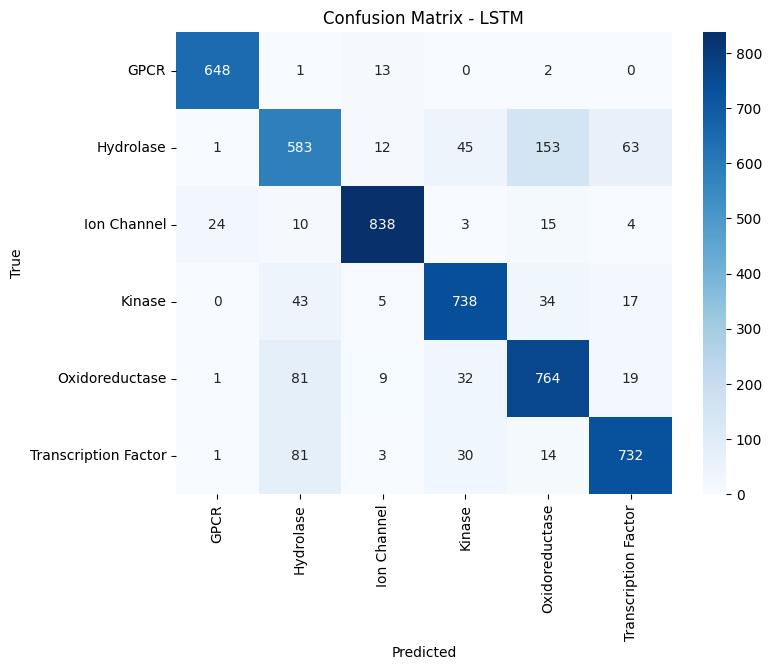

Model LSTM dan hasil evaluasi berhasil disimpan.


In [13]:
# 5. Evaluasi Metrik dan Simpan Model
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for seqs, labels in test_loader:
        seqs = seqs.to(device)
        outputs = model(seqs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n--- Classification Report ---")
class_names = [label_mapping[str(i)] for i in range(num_classes)]
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)

mcc = matthews_corrcoef(all_labels, all_preds)
print(f"\nMCC Score: {mcc:.4f}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - LSTM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Simpan metrik performa
results = {
    'accuracy': accuracy_score(all_labels, all_preds),
    'f1_macro': f1_score(all_labels, all_preds, average='macro'),
    'mcc': mcc,
    'history': history
}
with open('data/results/lstm_metrics.json', 'w') as f:
    json.dump(results, f)

# Simpan bobot (weights) model
torch.save(model.state_dict(), 'models/lstm_model.pth')
print("Model LSTM dan hasil evaluasi berhasil disimpan.")

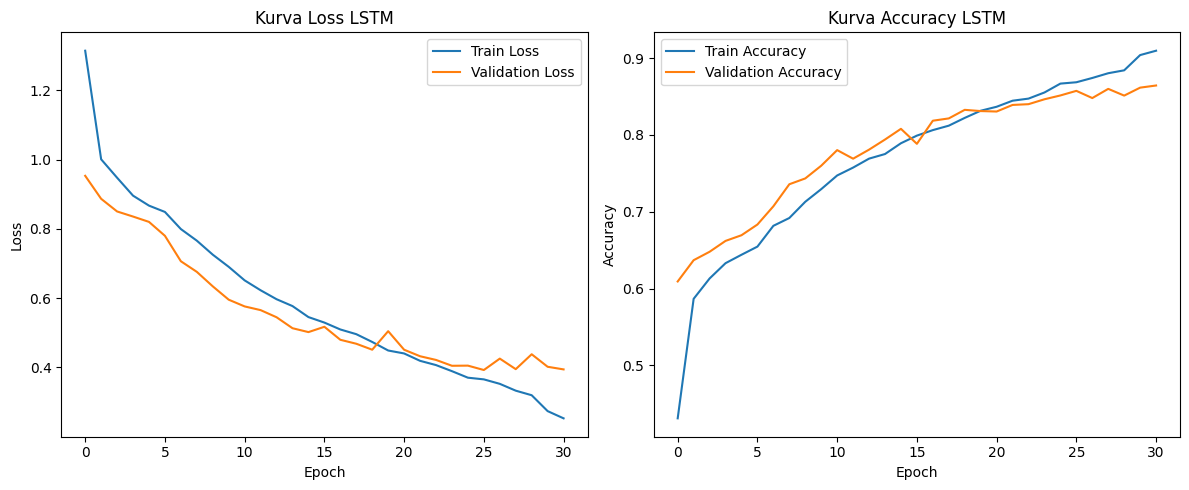

In [14]:
# 6. Visualisasi Kurva Loss & Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Kurva Loss LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Kurva Accuracy LSTM')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()